We can use this

```
def to_binary_16(n, to_binary_8):
    high = n // 256
    low  = n % 256
    return to_binary_8(high) + to_binary_8(low)
```

But we need to approximate the two functions over [0, 2^16]... let's see

In [39]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [40]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

Idea: % 256 si può fare con double angle senza troppa profondità i guess, e il diviso?

In [63]:
def diviso(x):
    return x % 2

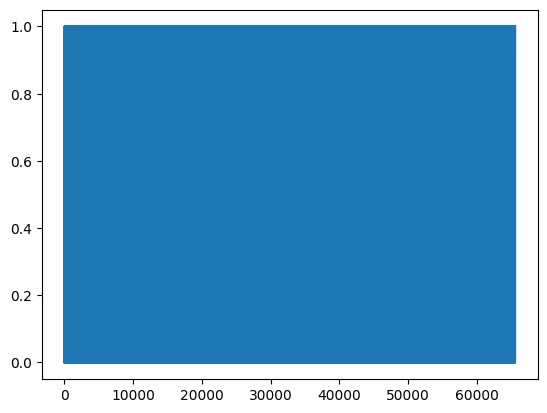

In [64]:
x = np.arange(0, 2**16, 1)

y = np.vectorize(diviso)(x)

plt.plot(x, y)

In [65]:
def polylut():
    N = 2**10
    seq = np.array([diviso(i) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

In [66]:
f = polylut()

In [67]:
x = np.arange(0, 2**10, 1)

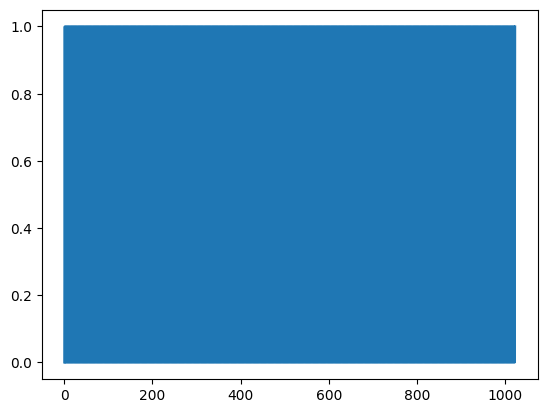

In [68]:
y_real = np.vectorize(f)(x)
plt.plot(x, y_real)

In [75]:
c = Chebyshev(0, 2**10, 1507, f)

1.1483061102692846

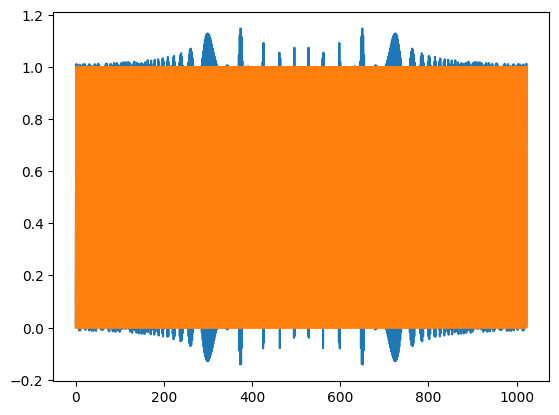

In [76]:
y = np.vectorize(c.eval)(x)
plt.plot(x, y)

y_real = np.vectorize(f)(x)
plt.plot(x, y_real)


max(abs(y - y_real))